In [32]:
import os
import subprocess
import tempfile
import shutil
import cv2
import numpy as np
import time
from skimage.metrics import structural_similarity as ssim
from matplotlib import pyplot as plt

def run_cpp_filter(input_image, output_image, filter_command):
    """
    Runs the C++ image filter command, measures execution time, and saves the output.
    """
    command = f"./build/APImageFilters -i {input_image} {filter_command} {output_image}"
    print(f"Running C++ command: {command}")
    start_time = time.time()
    subprocess.run(command, shell=True, check=True)
    elapsed_time = time.time() - start_time
    print(f"C++ Execution Time: {elapsed_time:.4f} seconds")
    return elapsed_time

import subprocess
import time
import subprocess
import time

# def run_imagemagick_filter(input_image, output_image, magick_command):
#     """
#     Runs the ImageMagick filter command, measures execution time, and saves the output.
#     Handles edge detection correctly using Morphology.
#     """
#     # Special handling for edge detection since `-edge` doesn't exist
#     if magick_command == "-edge":
#         command = f"magick {input_image} -morphology Convolve Sobel {output_image}"
#     else:
#         command = f"magick {input_image} {magick_command} {output_image}"
    
#     print(f"Running ImageMagick command: {command}")
#     start_time = time.time()

#     try:
#         subprocess.run(command, shell=True, check=True)
#     except subprocess.CalledProcessError as e:
#         print(f"Error: ImageMagick command failed with error:\n{e.stderr}")
#         return None

#     elapsed_time = time.time() - start_time
#     print(f"ImageMagick Execution Time: {elapsed_time:.4f} seconds")
#     return elapsed_time

def run_imagemagick_filter(input_image, output_image, magick_command):
    """
    Runs the ImageMagick filter command, measures execution time, and saves the output.
    Handles edge detection correctly using Morphology.
    """
    # Use "convert" instead of "magick" since ImageMagick 6 does not support "magick" command
    imagemagick_cmd = "convert"  # Change from "magick" to "convert"

    # Special handling for edge detection since `-edge` doesn't exist in ImageMagick 6
    if magick_command == "-edge":
        command = f"{imagemagick_cmd} {input_image} -morphology Convolve Sobel {output_image}"
    else:
        command = f"{imagemagick_cmd} {input_image} {magick_command} {output_image}"
    
    print(f"Running ImageMagick command: {command}")
    start_time = time.time()

    try:
        subprocess.run(command, shell=True, check=True)
    except subprocess.CalledProcessError as e:
        print(f"Error: ImageMagick command failed with error:\n{e.stderr}")
        return None

    elapsed_time = time.time() - start_time
    print(f"ImageMagick Execution Time: {elapsed_time:.4f} seconds")
    return elapsed_time


def compare_images(image1_path, image2_path, title1="C++ Output", title2="ImageMagick Output"):
    """
    Displays two images side by side for comparison. Detects if images are color or grayscale.
    """
    img1 = cv2.imread(image1_path)  # Load with color detection
    img2 = cv2.imread(image2_path)

    # Convert to RGB (OpenCV loads as BGR by default)
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    # Determine color mode
    is_grayscale = len(img1.shape) == 2 or img1.shape[2] == 1

    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img1, cmap='gray' if is_grayscale else None)
    plt.title(title1)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img2, cmap='gray' if is_grayscale else None)
    plt.title(title2)
    plt.axis("off")

    plt.show()

def calculate_image_difference(image1_path, image2_path):
    """
    Computes the Mean Squared Error (MSE) and Structural Similarity Index (SSIM) between two images.
    """
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)

    # Ensure both images are the same size
    if img1.shape != img2.shape:
        print("Warning: Images have different dimensions, resizing the second image.")
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    # Compute MSE
    mse = np.mean((img1.astype("float") - img2.astype("float")) ** 2)

    # Compute SSIM
    ssim_value = ssim(img1, img2)

    return mse, ssim_value

def test_filter(input_image, cpp_filter, magick_filter):
    """
    Runs both C++ and ImageMagick filters, compares the results, prints execution times and image similarity.
    """
    temp_dir = tempfile.mkdtemp()
    cpp_output = os.path.join(temp_dir, "output_cpp.png")
    magick_output = os.path.join(temp_dir, "output_magick.png")

    try:
        cpp_time = run_cpp_filter(input_image, cpp_output, cpp_filter)
        magick_time = run_imagemagick_filter(input_image, magick_output, magick_filter)
        compare_images(cpp_output, magick_output)

        # Calculate Image Differences
        mse, ssim_value = calculate_image_difference(cpp_output, magick_output)

        print("\n===== Performance & Similarity Comparison =====")
        print(f"C++ Execution Time: {cpp_time:.4f} seconds")
        print(f"ImageMagick Execution Time: {magick_time:.4f} seconds")
        print(f"MSE (Mean Squared Error): {mse:.4f} (Lower is better)")
        print(f"SSIM (Structural Similarity Index): {ssim_value:.4f} (Higher is better)")

    finally:
        shutil.rmtree(temp_dir)
        
def run_opencv_blur(input_image, output_image, blur_type, kernel_size, sigma=0):
    """
    Applies Gaussian or Box blur using OpenCV and saves the output.
    """
    img = cv2.imread(input_image)

    start_time = time.time()

    if blur_type == "Gaussian":
        blurred_img = cv2.GaussianBlur(img, (kernel_size, kernel_size), sigma)
    elif blur_type == "Box":
        blurred_img = cv2.blur(img, (kernel_size, kernel_size))
    else:
        raise ValueError("Unsupported blur type. Use 'Gaussian' or 'Box'.")

    cv2.imwrite(output_image, blurred_img)
    
    elapsed_time = time.time() - start_time
    print(f"OpenCV ({blur_type}) Execution Time: {elapsed_time:.4f} seconds")
    return elapsed_time

def test_filter_with_opencv(input_image, cpp_filter, blur_type, kernel_size=None, sigma=0):
    """
    Runs both C++ and OpenCV filters, compares the results, and prints execution times & image similarity.
    """
    temp_dir = tempfile.mkdtemp()
    cpp_output = os.path.join(temp_dir, "output_cpp.png")
    opencv_output = os.path.join(temp_dir, "output_opencv.png")

    try:
        cpp_time = run_cpp_filter(input_image, cpp_output, cpp_filter)
        opencv_time = run_opencv_blur(input_image, opencv_output, blur_type, kernel_size, sigma)
        compare_images(cpp_output, opencv_output)

        # Calculate Image Differences
        mse, ssim_value = calculate_image_difference(cpp_output, opencv_output)

        print("\n===== Performance & Similarity Comparison =====")
        print(f"C++ Execution Time: {cpp_time:.4f} seconds")
        print(f"OpenCV ({blur_type}) Execution Time: {opencv_time:.4f} seconds")
        print(f"MSE (Mean Squared Error): {mse:.4f} (Lower is better)")
        print(f"SSIM (Structural Similarity Index): {ssim_value:.4f} (Higher is better)")

    finally:
        shutil.rmtree(temp_dir)
        

def run_opencv_edge_detection(input_image, output_image):
    """
    Applies Sobel edge detection using OpenCV and saves the output.
    """
    img = cv2.imread(input_image, cv2.IMREAD_GRAYSCALE)

    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    sobel_edges = cv2.magnitude(sobel_x, sobel_y)
    sobel_edges = np.uint8(255 * sobel_edges / np.max(sobel_edges))  # Normalize

    cv2.imwrite(output_image, sobel_edges)

Running C++ command: ./build/APImageFilters -i Images/gracehopper.png -g /tmp/tmp0jd8opfj/output_cpp.png
C++ Execution Time: 0.0959 seconds
Running ImageMagick command: convert Images/gracehopper.png -colorspace Gray /tmp/tmp0jd8opfj/output_magick.png
ImageMagick Execution Time: 0.1513 seconds


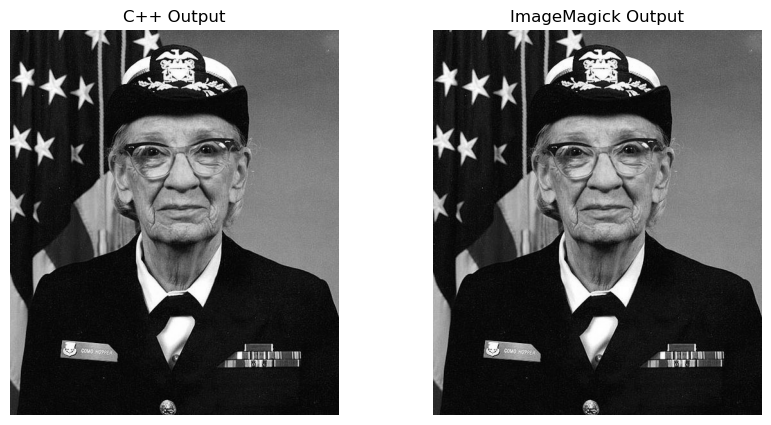


===== Performance & Similarity Comparison =====
C++ Execution Time: 0.0959 seconds
ImageMagick Execution Time: 0.1513 seconds
MSE (Mean Squared Error): 0.0051 (Lower is better)
SSIM (Structural Similarity Index): 1.0000 (Higher is better)


In [15]:
input_image = "Images/gracehopper.png"
test_filter(input_image, "-g", "-colorspace Gray")

# why '-' doen not work?

Running C++ command: ./build/APImageFilters -i Images/gracehopper.png -b 100 /tmp/tmpp6qitm_3/output_cpp.png
C++ Execution Time: 0.2145 seconds
Running ImageMagick command: convert Images/gracehopper.png -brightness-contrast 39.2x0 /tmp/tmpp6qitm_3/output_magick.png
ImageMagick Execution Time: 0.2124 seconds


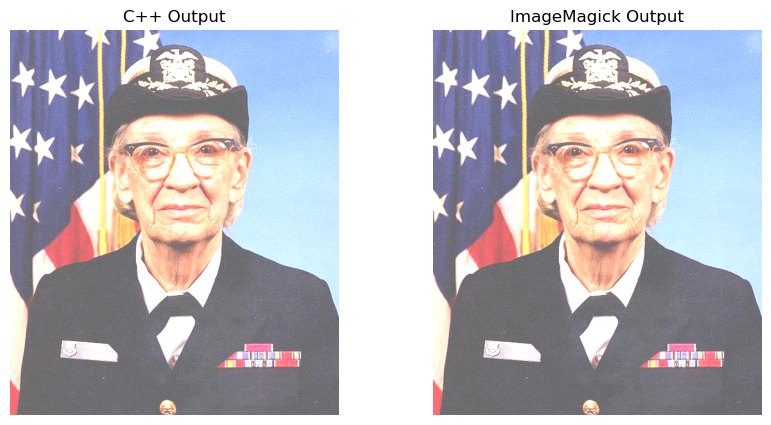


===== Performance & Similarity Comparison =====
C++ Execution Time: 0.2145 seconds
ImageMagick Execution Time: 0.2124 seconds
MSE (Mean Squared Error): 0.8427 (Lower is better)
SSIM (Structural Similarity Index): 0.9996 (Higher is better)


In [38]:
input_image = "Images/gracehopper.png"
test_filter(input_image, "-b 100", "-brightness-contrast 39.2x0")  # Scaled from -255 to 255 range

In [ ]:
# input_image = "Images/gracehopper.png"
# test_filter(input_image, "-h HSV", "-equalize")

Running C++ command: ./build/APImageFilters -i Images/gracehopper.png -r Gaussian 5 2.0 /tmp/tmpvdqi0me3/output_cpp.png
C++ Execution Time: 0.3733 seconds
OpenCV (Gaussian) Execution Time: 0.0215 seconds


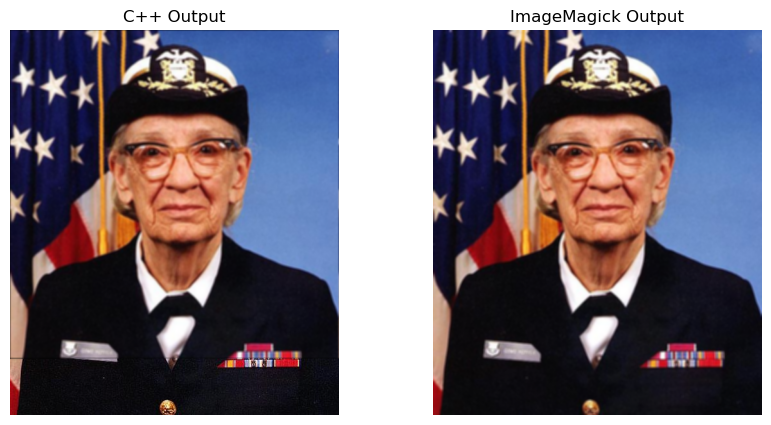


===== Performance & Similarity Comparison =====
C++ Execution Time: 0.3733 seconds
OpenCV (Gaussian) Execution Time: 0.0215 seconds
MSE (Mean Squared Error): 27.1866 (Lower is better)
SSIM (Structural Similarity Index): 0.9658 (Higher is better)


In [32]:
input_image = "Images/gracehopper.png"
test_filter_with_opencv(input_image, "-r Gaussian 5 2.0", "Gaussian", 5, 2.0)

Running C++ command: ./build/APImageFilters -i Images/gracehopper.png -r Box 7 /tmp/tmp0fglmg7g/output_cpp.png
C++ Execution Time: 0.2130 seconds
OpenCV (Box) Execution Time: 0.0163 seconds


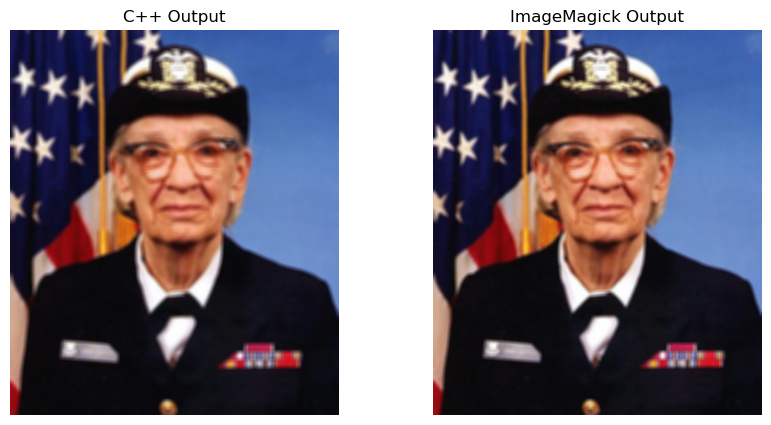


===== Performance & Similarity Comparison =====
C++ Execution Time: 0.2130 seconds
OpenCV (Box) Execution Time: 0.0163 seconds
MSE (Mean Squared Error): 21.4005 (Lower is better)
SSIM (Structural Similarity Index): 0.9802 (Higher is better)


In [33]:
input_image = "Images/gracehopper.png"
test_filter_with_opencv(input_image, "-r Box 7", "Box", 7)

Running C++ command: ./build/APImageFilters -i Images/bourton.png -r Gaussian 11 /tmp/tmppkmqu95g/output_cpp.png
C++ Execution Time: 23.8380 seconds
Running ImageMagick command: convert Images/bourton.png -gaussian 11 /tmp/tmppkmqu95g/output_magick.png
ImageMagick Execution Time: 6.9762 seconds


[ WARN:0@2992.347] global grfmt_png.cpp:695 read_chunk chunk data is too large


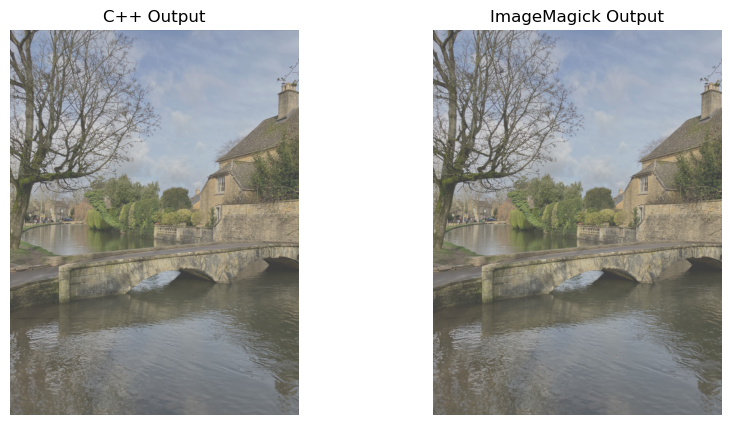

[ WARN:0@2994.959] global grfmt_png.cpp:695 read_chunk chunk data is too large



===== Performance & Similarity Comparison =====
C++ Execution Time: 23.8380 seconds
ImageMagick Execution Time: 6.9762 seconds
MSE (Mean Squared Error): 7.0083 (Lower is better)
SSIM (Structural Similarity Index): 0.9731 (Higher is better)


In [35]:
input_image = "Images/bourton.png"
test_filter(input_image, "-r Gaussian 11", "-gaussian 11")

In [2]:
def run_cpp_filter(input_image, output_image, filter_command):
    """
    Runs the C++ image filter command and measures execution time.
    """
    command = f"./build/APImageFilters -i {input_image} {filter_command} {output_image}"
    print(f"Running C++ command: {command}")
    start_time = time.time()
    subprocess.run(command, shell=True, check=True)
    elapsed_time = time.time() - start_time
    print(f"C++ Execution Time: {elapsed_time:.4f} seconds")
    return elapsed_time

def run_opencv_edge_detection(input_image, output_image, filter_name):
    """
    Applies edge detection using OpenCV and saves the output.
    Supports Sobel, Prewitt, Scharr, and Roberts’ Cross filters.
    """
    img = cv2.imread(input_image, cv2.IMREAD_GRAYSCALE)
    start_time = time.time()

    if filter_name == "Sobel":
        gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    elif filter_name == "Prewitt":
        gx = cv2.filter2D(img, -1, np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float64))
        gy = cv2.filter2D(img, -1, np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float64))
    elif filter_name == "Scharr":
        gx = cv2.Scharr(img, cv2.CV_64F, 1, 0)
        gy = cv2.Scharr(img, cv2.CV_64F, 0, 1)
    elif filter_name == "Roberts":
        gx = cv2.filter2D(img, -1, np.array([[1, 0], [0, -1]], dtype=np.float64))
        gy = cv2.filter2D(img, -1, np.array([[0, 1], [-1, 0]], dtype=np.float64))
    else:
        raise ValueError(f"Unsupported filter: {filter_name}")

    gx = gx.astype(np.float64)
    gy = gy.astype(np.float64)

    # if gx.shape != gy.shape:
    #     print(f"Warning: gx shape {gx.shape} != gy shape {gy.shape}, resizing gy.")
    #     gy = cv2.resize(gy, (gx.shape[1], gx.shape[0]))

    edge_img = cv2.magnitude(gx, gy)
    cv2.imwrite(output_image, edge_img)

    elapsed_time = time.time() - start_time
    print(f"OpenCV ({filter_name}) Execution Time: {elapsed_time:.4f} seconds")
    return elapsed_time


def compare_images(image1_path, image2_path, title1="C++ Output", title2="ImageMagick Output"):
    """
    Displays two images side by side for comparison.
    """
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img1, cmap='gray')
    plt.title(title1)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img2, cmap='gray')
    plt.title(title2)
    plt.axis("off")

    plt.show()

def calculate_image_difference(image1_path, image2_path):
    """
    Computes Mean Squared Error (MSE) and Structural Similarity Index (SSIM).
    """
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)

    # Resize if needed
    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    mse = np.mean((img1.astype("float") - img2.astype("float")) ** 2)
    ssim_value = ssim(img1, img2)

    return mse, ssim_value

def test_edge_detection(input_image, cpp_filter, filter_name):
    """
    Tests edge detection using C++, ImageMagick, and OpenCV, then compares results.
    """
    temp_dir = tempfile.mkdtemp()
    cpp_output = os.path.join(temp_dir, "output_cpp.png")
    opencv_output = os.path.join(temp_dir, "output_opencv.png")

    try:
        # Run filters
        cpp_time = run_cpp_filter(input_image, cpp_output, cpp_filter)
        opencv_time = run_opencv_edge_detection(input_image, opencv_output, filter_name)

        # Compare results
        compare_images(cpp_output, opencv_output, "C++ Output", "OpenCV Output")

        # Compute differences
        mse_cpp_opencv, ssim_cpp_opencv = calculate_image_difference(cpp_output, opencv_output)

        print("\n===== Performance & Similarity Comparison =====")
        print(f"C++ Execution Time: {cpp_time:.4f} seconds")
        print(f"OpenCV Execution Time: {opencv_time:.4f} seconds")

        print(f"MSE (C++ vs OpenCV): {mse_cpp_opencv:.4f}")
        print(f"SSIM (C++ vs OpenCV): {ssim_cpp_opencv:.4f}")

    finally:
        shutil.rmtree(temp_dir)

Running C++ command: ./build/APImageFilters -i Images/gracehopper.png --edge Sobel /tmp/tmpsr78iy_q/output_cpp.png
Applying edge detection filter: Sobel
C++ Execution Time: 0.1291 seconds
OpenCV (Sobel) Execution Time: 0.0129 seconds


[ WARN:0@23.856] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


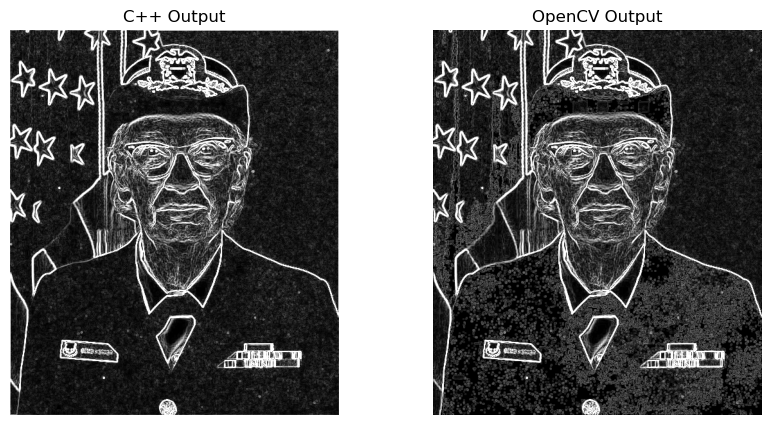


===== Performance & Similarity Comparison =====
C++ Execution Time: 0.1291 seconds
OpenCV Execution Time: 0.0129 seconds
MSE (C++ vs OpenCV): 646.9275
SSIM (C++ vs OpenCV): 0.7471


In [4]:
input_image = "Images/gracehopper.png"
test_edge_detection(input_image, "--edge Sobel", "Sobel")

Running C++ command: ./build/APImageFilters -i Images/gracehopper.png -e Prewitt /tmp/tmpdy7c7r6u/output_cpp.png
Applying edge detection filter: Prewitt
C++ Execution Time: 0.1065 seconds
OpenCV (Prewitt) Execution Time: 0.0086 seconds


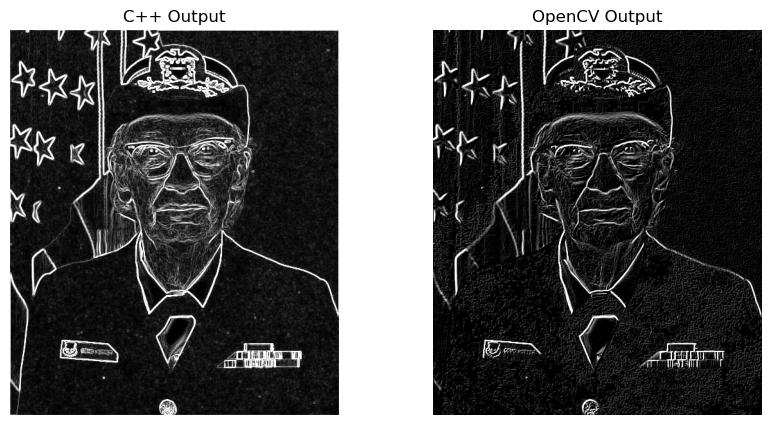


===== Performance & Similarity Comparison =====
C++ Execution Time: 0.1065 seconds
OpenCV Execution Time: 0.0086 seconds
MSE (C++ vs OpenCV): 2180.6652
SSIM (C++ vs OpenCV): 0.4534


In [ ]:
test_edge_detection(input_image, "-e Prewitt", "Prewitt")

Running C++ command: ./build/APImageFilters -i Images/gracehopper.png -e Scharr /tmp/tmpp9ljrk5r/output_cpp.png
Applying edge detection filter: Scharr
C++ Execution Time: 0.1150 seconds
OpenCV (Scharr) Execution Time: 0.0077 seconds


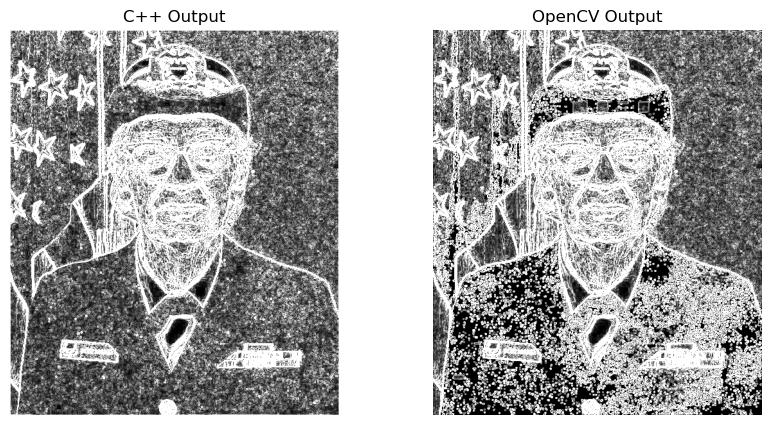


===== Performance & Similarity Comparison =====
C++ Execution Time: 0.1150 seconds
OpenCV Execution Time: 0.0077 seconds
MSE (C++ vs OpenCV): 4307.3986
SSIM (C++ vs OpenCV): 0.7065


In [6]:
test_edge_detection(input_image, "-e Scharr", "Scharr")

Running C++ command: ./build/APImageFilters -i Images/gracehopper.png -e RobertsCross /tmp/tmpxpezln5b/output_cpp.png
Applying edge detection filter: RobertsCross
C++ Execution Time: 0.0965 seconds
OpenCV (Roberts) Execution Time: 0.0072 seconds


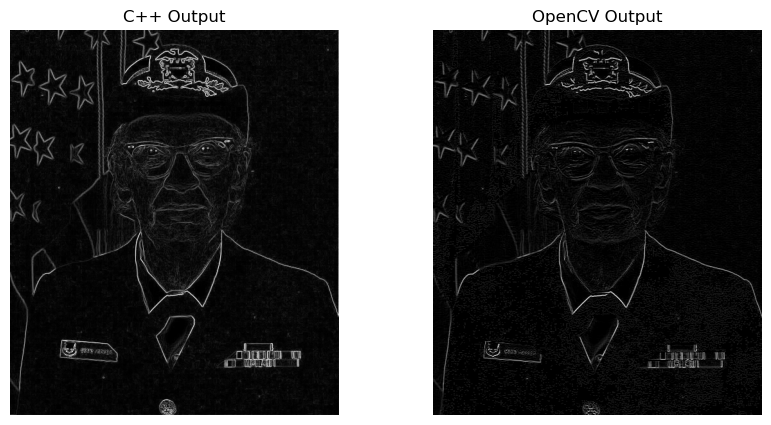


===== Performance & Similarity Comparison =====
C++ Execution Time: 0.0965 seconds
OpenCV Execution Time: 0.0072 seconds
MSE (C++ vs OpenCV): 702.3713
SSIM (C++ vs OpenCV): 0.3737


In [7]:
test_edge_detection(input_image, "-e RobertsCross", "Roberts")

In [85]:
def run_cpp_filter(input_image, output_image, filter_command):
    """
    Runs the C++ image filter command and measures execution time.
    """
    command = f"./build/APImageFilters -i {input_image} {filter_command} {output_image}"
    print(f"Running C++ command: {command}")
    start_time = time.time()
    subprocess.run(command, shell=True, check=True)
    elapsed_time = time.time() - start_time
    print(f"C++ Execution Time: {elapsed_time:.4f} seconds")
    return elapsed_time

def run_opencv_sharpening(input_image, output_image):
    """
    Applies image sharpening using OpenCV with the Laplacian filter.
    """
    img = cv2.imread(input_image, cv2.IMREAD_GRAYSCALE)
    start_time = time.time()

    # 3x3 Laplacian kernel for sharpening
    laplacian_kernel = np.array([[ 0, -1,  0],
                                  [-1,  4, -1],
                                  [ 0, -1,  0]], dtype=np.float32)

    # Apply filter
    sharpened_img = cv2.filter2D(img, -1, laplacian_kernel)
    
    # Add the original image to the filtered image
    result = cv2.add(img, sharpened_img)

    # Save the result
    cv2.imwrite(output_image, result)

    elapsed_time = time.time() - start_time
    print(f"OpenCV Sharpening Execution Time: {elapsed_time:.4f} seconds")
    return elapsed_time

def compare_images(image1_path, image2_path, title1="C++ Output", title2="OpenCV Output"):
    """
    Displays two images side by side for comparison.
    """
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)

    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(img1, cmap='gray')
    plt.title(title1)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img2, cmap='gray')
    plt.title(title2)
    plt.axis("off")

    plt.show()

def calculate_image_difference(image1_path, image2_path):
    """
    Computes Mean Squared Error (MSE) and Structural Similarity Index (SSIM).
    """
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)

    # Resize if needed
    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    mse = np.mean((img1.astype("float") - img2.astype("float")) ** 2)
    ssim_value = ssim(img1, img2)

    return mse, ssim_value

def test_sharpening_filter(input_image, cpp_filter):
    """
    Tests image sharpening using C++ and OpenCV, then compares results.
    """
    temp_dir = tempfile.mkdtemp()
    cpp_output = os.path.join(temp_dir, "output_cpp.png")
    opencv_output = os.path.join(temp_dir, "output_opencv.png")

    try:
        # Run filters
        cpp_time = run_cpp_filter(input_image, cpp_output, cpp_filter)
        opencv_time = run_opencv_sharpening(input_image, opencv_output)

        # Compare results
        compare_images(cpp_output, opencv_output, "C++ Output", "OpenCV Output")

        # Compute differences
        mse_cpp_opencv, ssim_cpp_opencv = calculate_image_difference(cpp_output, opencv_output)

        print("\n===== Performance & Similarity Comparison =====")
        print(f"C++ Execution Time: {cpp_time:.4f} seconds")
        print(f"OpenCV Execution Time: {opencv_time:.4f} seconds")

        print(f"MSE (C++ vs OpenCV): {mse_cpp_opencv:.4f}")
        print(f"SSIM (C++ vs OpenCV): {ssim_cpp_opencv:.4f}")

    finally:
        shutil.rmtree(temp_dir)

Running C++ command: ./build/APImageFilters -i Images/gracehopper.png -p /tmp/tmpr6a__h83/output_cpp.png
C++ Execution Time: 0.2957 seconds
OpenCV Sharpening Execution Time: 0.0043 seconds


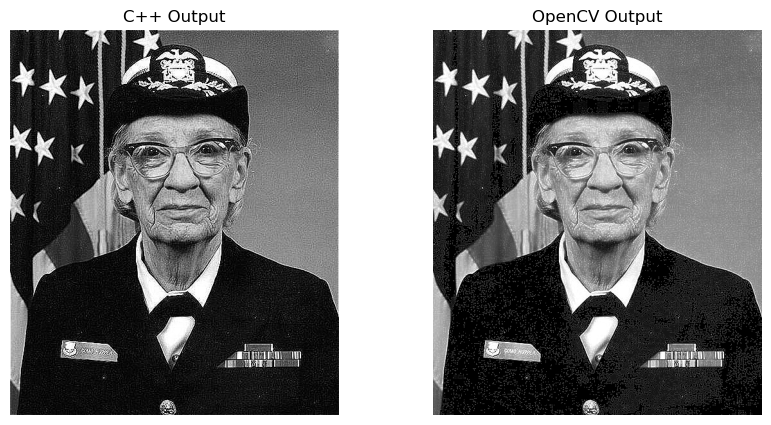


===== Performance & Similarity Comparison =====
C++ Execution Time: 0.2957 seconds
OpenCV Execution Time: 0.0043 seconds
MSE (C++ vs OpenCV): 434.1783
SSIM (C++ vs OpenCV): 0.7254


In [88]:
test_sharpening_filter(input_image, "-p")


In [ ]:
def load_image_stack(folder, z_range=None):
    """
    Load a sequence of 2D images from a folder as a 3D NumPy array.
    
    Args:
        folder (str): Path to the folder containing images.
        z_range (tuple): (min_z, max_z), indices of slices to load.
    
    Returns:
        volume (numpy.ndarray): 3D volume of shape (Z, H, W).
    """
    filenames = sorted([f for f in os.listdir(folder) if f.endswith(('.png', '.jpg', '.tif'))])
    
    if z_range:
        filenames = filenames[z_range[0]-1:z_range[1]]  # Adjust for 1-based input

    images = [cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE) for f in filenames]
    volume = np.stack(images, axis=0)  # Shape: (Z, H, W)
    
    return volume

def mip(volume):
    """ Maximum Intensity Projection (MIP) along the Z-axis. """
    return np.max(volume, axis=0)

def minip(volume):
    """ Minimum Intensity Projection (MinIP) along the Z-axis. """
    return np.min(volume, axis=0)

def aip(volume):
    """ Average Intensity Projection (AIP) along the Z-axis. """
    return np.mean(volume, axis=0).astype(np.uint8)

def median_aip(volume):
    """ Median Intensity Projection along the Z-axis. """
    return np.median(volume, axis=0).astype(np.uint8)

def test_orthographic_projections(folder, z_range=None):
    """
    Load a 3D image stack and compute MIP, MinIP, AIP, and Median AIP.
    """
    volume = load_image_stack(folder, z_range)
    
    mip_result = mip(volume)
    minip_result = minip(volume)
    aip_result = aip(volume)
    median_aip_result = median_aip(volume)

    projections = {
        "Maximum Intensity Projection (MIP)": mip_result,
        "Minimum Intensity Projection (MinIP)": minip_result,
        "Average Intensity Projection (AIP)": aip_result,
        "Median Intensity Projection": median_aip_result
    }

    # Display results
    plt.figure(figsize=(12, 6))
    for i, (title, img) in enumerate(projections.items()):
        plt.subplot(2, 2, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    
    plt.show()


def run_opencv_projection(folder, output_image, projection_type, z_range=None):
    volume = load_image_stack(folder, z_range)

    start_time = time.time()

    if projection_type == "MIP":
        result = np.max(volume, axis=0)  # Max projection along Z
    elif projection_type == "MinIP":
        result = np.min(volume, axis=0)  # Min projection along Z
    elif projection_type == "AIP":
        result = np.mean(volume, axis=0).astype(np.uint8)  # Mean projection
    elif projection_type == "MedianIP":
        result = np.median(volume, axis=0).astype(np.uint8)  # Median projection
    else:
        raise ValueError(f"Unsupported projection type: {projection_type}")

    cv2.imwrite(output_image, result)

    elapsed_time = time.time() - start_time
    print(f"OpenCV {projection_type} Execution Time: {elapsed_time:.4f} seconds")
    return elapsed_time

def run_cpp_projection(input_folder, output_image, projection_command):
    """
    Runs the C++ orthographic projection filter and measures execution time.
    
    Args:
        input_folder (str): Path to folder containing 3D image slices.
        output_image (str): Path to save the projection result.
        projection_command (str): C++ argument for projection type (e.g., "-mip", "-minip", "-aip").
    """
    command = f"./build/APImageFilters -d {input_folder} {projection_command} {output_image}"
    print(f"Running C++ command: {command}")
    start_time = time.time()
    subprocess.run(command, shell=True, check=True)
    elapsed_time = time.time() - start_time
    print(f"C++ Execution Time: {elapsed_time:.4f} seconds")
    return elapsed_time


def test_projection_filter(folder, cpp_filter, projection_type, z_range=None):
    """
    Tests image projection (MIP, MinIP, AIP) using C++ and OpenCV, then compares results.
    
    Args:
        folder (str): Path to 3D image stack.
        cpp_filter (str): C++ argument for projection type (e.g., "-mip", "-minip", "-aip").
        projection_type (str): One of ['MIP', 'MinIP', 'AIP', 'MedianIP']
        z_range (tuple): Optional (min_z, max_z) slice indices for thin slab projection.
    """
    temp_dir = tempfile.mkdtemp()
    cpp_output = os.path.join(temp_dir, "output_cpp.png")
    opencv_output = os.path.join(temp_dir, "output_opencv.png")

    try:
        # Run filters
        cpp_time = run_cpp_projection(folder, cpp_output, cpp_filter)
        opencv_time = run_opencv_projection(folder, opencv_output, projection_type, z_range)

        # Compare results
        compare_images(cpp_output, opencv_output, "C++ Output", "OpenCV Output")

        # Compute differences
        mse_cpp_opencv, ssim_cpp_opencv = calculate_image_difference(cpp_output, opencv_output)

        print("\n===== Performance & Similarity Comparison =====")
        print(f"C++ Execution Time: {cpp_time:.4f} seconds")
        print(f"OpenCV Execution Time: {opencv_time:.4f} seconds")

        print(f"MSE (C++ vs OpenCV): {mse_cpp_opencv:.4f}")
        print(f"SSIM (C++ vs OpenCV): {ssim_cpp_opencv:.4f}")

    finally:
        shutil.rmtree(temp_dir)



Running C++ command: ./build/APImageFilters -d Scans/TestVolume/vol/ -r Median 3 2.0
Saved blurred volume to ProcessedVolume/processed_volume
C++ Execution Time: 0.0484 seconds
OpenCV Median3D Execution Time: 0.3573 seconds

===== Execution Time Comparison =====
C++ Execution Time: 0.0484 seconds
OpenCV Execution Time: 0.3573 seconds


Running C++ command: ./build/APImageFilters -d Scans/fracture -p MIP /tmp/tmpdx_kjjmq/output_cpp.png
Saved volume result to /tmp/tmpdx_kjjmq/output_cpp.png
C++ Execution Time: 5.3796 seconds
OpenCV MIP Execution Time: 0.0317 seconds


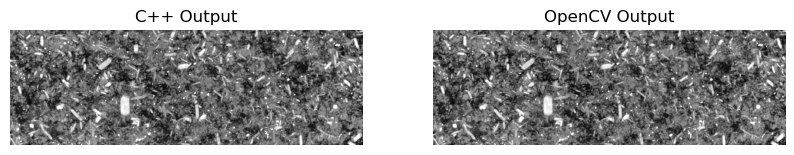


===== Performance & Similarity Comparison =====
C++ Execution Time: 5.3796 seconds
OpenCV Execution Time: 0.0317 seconds
MSE (C++ vs OpenCV): 0.0000
SSIM (C++ vs OpenCV): 1.0000


In [15]:
test_projection_filter("Scans/fracture", "-p MIP", "MIP")


Running C++ command: ./build/APImageFilters -d Scans/fracture -p MedianAIP /tmp/tmpdd3bniov/output_cpp.png
Saved volume result to /tmp/tmpdd3bniov/output_cpp.png
C++ Execution Time: 5.9032 seconds
OpenCV MedianIP Execution Time: 2.2075 seconds


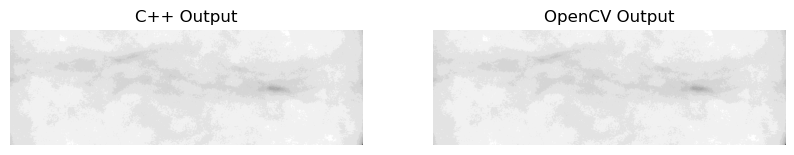


===== Performance & Similarity Comparison =====
C++ Execution Time: 5.9032 seconds
OpenCV Execution Time: 2.2075 seconds
MSE (C++ vs OpenCV): 0.0062
SSIM (C++ vs OpenCV): 0.9999


In [21]:
test_projection_filter("Scans/fracture", "-p MedianAIP", "MedianIP")


Running C++ command: ./build/APImageFilters -d Scans/fracture -p MinIP /tmp/tmpfr2qtc67/output_cpp.png
Saved volume result to /tmp/tmpfr2qtc67/output_cpp.png
C++ Execution Time: 8.2338 seconds
OpenCV MinIP Execution Time: 0.0235 seconds


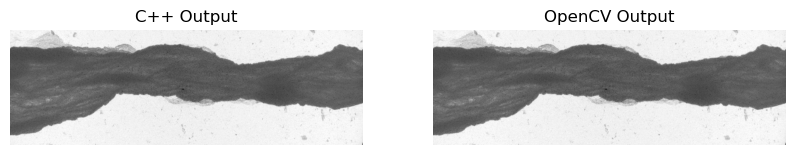


===== Performance & Similarity Comparison =====
C++ Execution Time: 8.2338 seconds
OpenCV Execution Time: 0.0235 seconds
MSE (C++ vs OpenCV): 0.0000
SSIM (C++ vs OpenCV): 1.0000


In [22]:
test_projection_filter("Scans/fracture", "-p MinIP", "MinIP")

Running C++ command: ./build/APImageFilters -d Scans/fracture -p AIP /tmp/tmp3r4c62tr/output_cpp.png
Saved volume result to /tmp/tmp3r4c62tr/output_cpp.png
C++ Execution Time: 8.3742 seconds
OpenCV AIP Execution Time: 0.1363 seconds


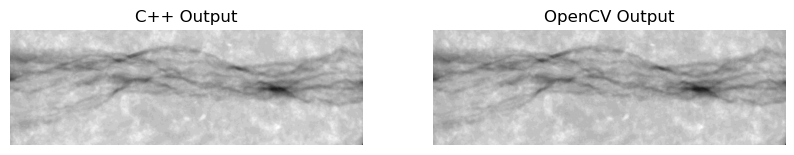


===== Performance & Similarity Comparison =====
C++ Execution Time: 8.3742 seconds
OpenCV Execution Time: 0.1363 seconds
MSE (C++ vs OpenCV): 0.4997
SSIM (C++ vs OpenCV): 0.9959


In [23]:
test_projection_filter("Scans/fracture", "-p AIP", "AIP")


### test the running time with opencv

In [ ]:
import os
import cv2
import numpy as np
import time
import subprocess
import tempfile
import shutil

def load_image_stack(folder, z_range=None):
    """
    Load a sequence of 2D images from a folder as a 3D NumPy array.
    
    Args:
        folder (str): Path to the folder containing images.
        z_range (tuple): (min_z, max_z), indices of slices to load.
    
    Returns:
        volume (numpy.ndarray): 3D volume of shape (Z, H, W).
    """
    filenames = sorted([f for f in os.listdir(folder) if f.endswith(('.png', '.jpg', '.tif'))])
    
    if z_range:
        filenames = filenames[z_range[0]-1:z_range[1]]  # Adjust for 1-based input

    images = [cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE) for f in filenames]
    volume = np.stack(images, axis=0)  # Shape: (Z, H, W)
    
    return volume

def apply_median_blur_3d(volume, kernel_size=3):
    """Applies a 3D median blur to the volume."""
    depth, height, width = volume.shape
    output_volume = np.zeros_like(volume)
    pad_size = kernel_size // 2
    padded_vol = np.pad(volume, pad_size, mode='edge')
    
    for z in range(depth):
        for y in range(height):
            for x in range(width):
                neighborhood = padded_vol[z:z+kernel_size, y:y+kernel_size, x:x+kernel_size]
                output_volume[z, y, x] = np.median(neighborhood)
    
    return output_volume

def run_opencv_3d_filter(folder, filter_type, kernel_size=3):
    """Loads the image stack and applies a 3D median blur using OpenCV."""
    volume = load_image_stack(folder)
    start_time = time.time()
    
    if filter_type == "Median3D":
        _ = apply_median_blur_3d(volume, kernel_size)
    else:
        raise ValueError("Unsupported filter type: " + filter_type)
    
    elapsed_time = time.time() - start_time
    print(f"OpenCV {filter_type} Execution Time: {elapsed_time:.4f} seconds")
    return elapsed_time

def run_cpp_3d_filter(input_folder, cpp_filter):
    """Runs the C++ 3D filter and measures execution time."""
    command = f"./build/APImageFilters -d {input_folder} {cpp_filter}"
    print(f"Running C++ command: {command}")
    start_time = time.time()
    subprocess.run(command, shell=True, check=True)
    elapsed_time = time.time() - start_time
    print(f"C++ Execution Time: {elapsed_time:.4f} seconds")
    return elapsed_time

def test_3D_filter(folder, cpp_filter, opencv_filter, kernel_size=3):
    """Compares execution time of C++ and OpenCV 3D filter implementations."""
    cpp_time = run_cpp_3d_filter(folder, cpp_filter)
    opencv_time = run_opencv_3d_filter(folder, opencv_filter, kernel_size)
    
    print("\n===== Execution Time Comparison =====")
    print(f"C++ Execution Time: {cpp_time:.4f} seconds")
    print(f"OpenCV Execution Time: {opencv_time:.4f} seconds")

# Example usage
folder = "Scans/TestVolume/vol/"
cpp_filter = "-r Median"
opencv_filter = "Median3D"
test_3D_filter(folder, cpp_filter, opencv_filter)

Running C++ command: ./build/APImageFilters -d Scans/TestVolume/vol/ -r Median 3 2.0
Saved blurred volume to ProcessedVolume/processed_volume
C++ Execution Time: 0.0264 seconds
OpenCV Median3D Execution Time: 0.3633 seconds

===== Execution Time Comparison =====
C++ Execution Time: 0.0264 seconds
OpenCV Execution Time: 0.3633 seconds


In [19]:
# Example usage
folder = "Scans/TestVolume/vol/"
cpp_filter = "-r Gaussian 3 2.0"
opencv_filter = "Median3D"
test_3D_filter(folder, cpp_filter, opencv_filter)

Running C++ command: ./build/APImageFilters -d Scans/TestVolume/vol/ -r Gaussian 3 2.0
Saved blurred volume to ProcessedVolume/processed_volume
C++ Execution Time: 0.0229 seconds
OpenCV Median3D Execution Time: 0.3623 seconds

===== Execution Time Comparison =====
C++ Execution Time: 0.0229 seconds
OpenCV Execution Time: 0.3623 seconds


In [11]:
import os
import cv2
import numpy as np
import time
import subprocess
import tempfile
import shutil

def load_image_stack(folder, z_range=None):
    """
    Load a sequence of 2D images from a folder as a 3D NumPy array.
    
    Args:
        folder (str): Path to the folder containing images.
        z_range (tuple): (min_z, max_z), indices of slices to load.
    
    Returns:
        volume (numpy.ndarray): 3D volume of shape (Z, H, W).
    """
    filenames = sorted([f for f in os.listdir(folder) if f.endswith(('.png', '.jpg', '.tif'))])
    
    if z_range:
        filenames = filenames[z_range[0]-1:z_range[1]]  # Adjust for 1-based input

    images = [cv2.imread(os.path.join(folder, f), cv2.IMREAD_GRAYSCALE) for f in filenames]
    volume = np.stack(images, axis=0)  # Shape: (Z, H, W)
    
    return volume

def apply_median_blur_3d(volume, kernel_size=3):
    """Applies a 3D median blur to the volume."""
    depth, height, width = volume.shape
    output_volume = np.zeros_like(volume)
    pad_size = kernel_size // 2
    padded_vol = np.pad(volume, pad_size, mode='edge')
    
    for z in range(depth):
        for y in range(height):
            for x in range(width):
                neighborhood = padded_vol[z:z+kernel_size, y:y+kernel_size, x:x+kernel_size]
                output_volume[z, y, x] = np.median(neighborhood)
    
    return output_volume

def run_opencv_3d_filter(folder, filter_type, kernel_size=3, output_folder="ProcessedVolume/opencv_output"):
    """Loads the image stack, applies a 3D median blur using OpenCV, and saves output."""
    volume = load_image_stack(folder)
    start_time = time.time()
    
    if filter_type == "Median3D":
        result_volume = apply_median_blur_3d(volume, kernel_size)
    else:
        raise ValueError("Unsupported filter type: " + filter_type)
    
    os.makedirs(output_folder, exist_ok=True)
    
    for i, img in enumerate(result_volume):
        output_path = os.path.join(output_folder, f"slice_{i:03d}.png")
        cv2.imwrite(output_path, img)
    
    elapsed_time = time.time() - start_time
    print(f"OpenCV {filter_type} Execution Time: {elapsed_time:.4f} seconds")
    return elapsed_time

def run_cpp_3d_filter(input_folder, cpp_filter):
    """Runs the C++ 3D filter and measures execution time."""
    command = f"./build/APImageFilters -d {input_folder} {cpp_filter}"
    print(f"Running C++ command: {command}")
    start_time = time.time()
    subprocess.run(command, shell=True, check=True)
    elapsed_time = time.time() - start_time
    print(f"C++ Execution Time: {elapsed_time:.4f} seconds")
    return elapsed_time

def test_3D_filter(folder, cpp_filter, opencv_filter, kernel_size=3):
    """Compares execution time of C++ and OpenCV 3D filter implementations."""
    cpp_time = run_cpp_3d_filter(folder, cpp_filter)
    opencv_time = run_opencv_3d_filter(folder, opencv_filter, kernel_size)
    
    print("\n===== Execution Time Comparison =====")
    print(f"C++ Execution Time: {cpp_time:.4f} seconds")
    print(f"OpenCV Execution Time: {opencv_time:.4f} seconds")

# Example usage
folder = "Scans/TestVolume/vol/"
cpp_filter = "-r Median 3"
opencv_filter = "Median3D"
test_3D_filter(folder, cpp_filter, opencv_filter)

Running C++ command: ./build/APImageFilters -d Scans/TestVolume/vol/ -r Median 3
C++ Execution Time: 0.0272 seconds
OpenCV Median3D Execution Time: 0.3450 seconds

===== Execution Time Comparison =====
C++ Execution Time: 0.0272 seconds
OpenCV Execution Time: 0.3450 seconds
